### K리그 경기 내 최종 패스 좌표 예측 AI 모델 개발

  - train.csv: (356,721행, 15열) 경기 이벤트 로그. 주요 컬럼은 game_id, period_id, episode_id, time_seconds, team_id, player_id, action_id, type_name,
    result_name, start_x/y, end_x/y, is_home, game_episode.
  - test.csv: (2,414행, 3열) 각 game_episode별 이벤트 로그 파일 경로(./test/<game>/<game_episode>.csv)만 포함.
  - sample_submission.csv: 예측 대상은 game_episode별 end_x, end_y 좌표 2개 컬럼.
  - match_info.csv: 228경기, 모두 2024 K League 1. 날짜 2024-03-01~2024-11-24, 평균 득점 홈 1.17 / 어웨이 0.90. 일부 스코어는 -1로 미기록.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

train_df = pd.read_csv('./data/open_track1/train.csv')
print(train_df.shape)
train_df.head()


(356721, 15)


,game_id,period_id,episode_id,time_seconds,team_id,player_id,action_id,type_name,result_name,start_x,start_y,end_x,end_y,is_home,game_episode
0,126283,1,1,0.667,2354,344559,0,Pass,Successful,52.418205,33.485444,31.322445,38.274752,True,126283_1
1,126283,1,1,3.667,2354,250036,2,Pass,Successful,32.013240,38.100808,37.371285,30.632980,True,126283_1
2,126283,1,1,4.968,2354,500145,4,Carry,NaN,37.371285,30.632980,38.391570,24.613144,True,126283_1
3,126283,1,1,8.200,2354,500145,5,Pass,Successful,38.391570,24.613144,34.573350,5.545468,True,126283_1
4,126283,1,1,11.633,2354,142106,7,Pass,Successful,34.578705,6.058256,21.274470,18.437112,True,126283_1


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356721 entries, 0 to 356720
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   game_id       356721 non-null  int64  
 1   period_id     356721 non-null  int64  
 2   episode_id    356721 non-null  int64  
 3   time_seconds  356721 non-null  float64
 4   team_id       356721 non-null  int64  
 5   player_id     356721 non-null  int64  
 6   action_id     356721 non-null  int64  
 7   type_name     356721 non-null  object 
 8   result_name   216467 non-null  object 
 9   start_x       356721 non-null  float64
 10  start_y       356721 non-null  float64
 11  end_x         356721 non-null  float64
 12  end_y         356721 non-null  float64
 13  is_home       356721 non-null  bool   
 14  game_episode  356721 non-null  object 
dtypes: bool(1), float64(5), int64(6), object(3)
memory usage: 38.4+ MB


In [10]:
print(train_df['game_id'].nunique())
print(train_df['game_id'].value_counts())


198
game_id
126389    2153
126399    2142
126313    2113
126338    2085
126359    2057
          ... 
126448    1585
126450    1576
126434    1561
126459    1523
126451    1455
Name: count, Length: 198, dtype: int64


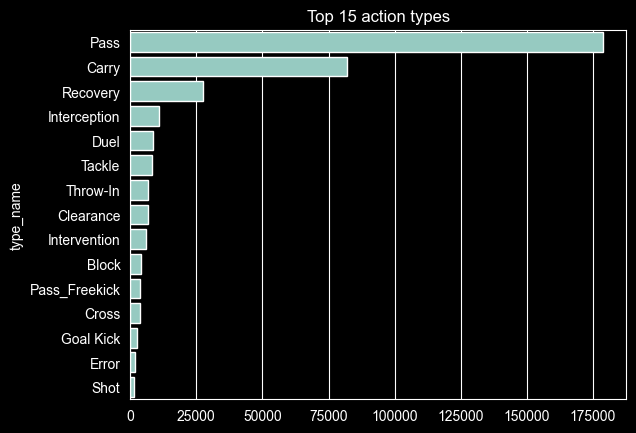

In [12]:
sns.barplot(y=train_df['type_name'].value_counts(ascending=False).head(15).index,
            x=train_df['type_name'].value_counts(ascending=False).head(15).values)
plt.title("Top 15 action types")
plt.show()